# Prediksi Harga Rumah di Depok — Machine Learning (CRISP-DM)

Notebook ini adalah pembaruan dari `dataMining_fixed.ipynb`, mengikuti kerangka **CRISP-DM**. Data mentah `Raw-Final-Rumah.csv` memiliki masalah `column shifting` dan format data yang kotor. Pembaruan utama meliputi: rekonstruksi baris berbasis konten, penanganan outlier dengan pemangkasan persentil, penyeragaman fitur turunan, penambahan **Stacking Ensemble** (Random Forest, HistGradientBoosting, Ridge sebagai base learners; Ridge sebagai meta-learner), dan interpretasi model dengan **SHAP**.

**Penjelasan untuk satu prediksi individual (waterfall plot).** Menjelaskan mengapa satu rumah diprediksi dengan harga tertentu.

## 0. Setup & Reproducibility

Untuk reproduktifitas, semua proses acak menggunakan `SEED` global yang sama.

In [1]:
!pip install -q optuna xgboost lightgbm shap openpyxl

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)

## 1. Business Understanding

Tujuan: membangun model regresi untuk prediksi harga rumah di Depok berdasarkan karakteristik fisik dan lokasi. Kriteria sukses: model memiliki error yang interpretable dan R² tinggi. Pertanyaan kunci: apakah Stacking Ensemble meningkatkan akurasi dibandingkan model tunggal terbaik?

## 2. Data Understanding

### 2.1 Import Library & Load Data

Data `Raw-Final-Rumah.csv` dimuat. Jika gagal, unggah manual ke `/content/Raw-Final-Rumah.csv`.

In [2]:
!pip install -q gdown

import gdown
import os

# Ganti dengan File ID milik Anda apabila berbeda dari notebook acuan
file_id = '1TAlyQiURtczeIQ6d6jWtADFIAjSM09pp'
url = f'https://drive.google.com/uc?id={file_id}'
output_path = '/content/Raw-Final-Rumah.csv'

try:
    gdown.download(url, output_path, quiet=False)
except Exception as e:
    print("Gagal download otomatis via gdown:", e)

if not os.path.exists(output_path):
    raise FileNotFoundError(
        "Raw-Final-Rumah.csv tidak ditemukan. Unggah file secara manual ke Colab "
        "(ikon folder di sisi kiri) lalu simpan pada path '/content/Raw-Final-Rumah.csv'."
    )

df_raw = pd.read_csv(output_path, dtype=str)  # baca sebagai string dulu, semua kolom masih kotor
print(df_raw.shape)
df_raw.head(10)

Downloading...
From: https://drive.google.com/uc?id=1TAlyQiURtczeIQ6d6jWtADFIAjSM09pp
To: /content/Raw-Final-Rumah.csv
100%|██████████| 2.15M/2.15M [00:00<00:00, 58.6MB/s]


(40200, 8)


,Harga,Kamar Tidur,Kamar Mandi,Garasi,Luas Tanah,Luas Bangunan,Kecamatan,Page
0,"2,5 Miliar",4,3,10,LT : 438 m²,LB : 110 m²,Tapos,129
1,385 Juta,3,2,1,LT : 50 m²,LB : 60 m²,Pancoran Mas,129
2,385 Juta,3,2,1,LT : 50 m²,LB : 60 m²,Cipayung,129
3,385 Juta,3,2,1,LT : 50 m²,LB : 60 m²,Rangkapanjaya,129
4,385 Juta,3,2,1,LT : 50 m²,LB : 60 m²,Pancoran Mas,129
5,385 Juta,3,2,1,LT : 50 m²,LB : 60 m²,Cipayung,129
6,950 Juta,2,1,1,LT : 87 m²,LB : 50 m²,Sawangan,129
7,525 Juta,2,1,LB:41 m²,NaN,NaN,Cinere,129
8,"2,5 Miliar",3,2,LT:409 m²,LB : 300 m²,NaN,Sukmajaya,129
9,"3,7 Miliar",4,3,LT:280 m²,LB : 240 m²,NaN,Cinere,129


### 2.1.1 Load Variabel Tambahan (Excel)

Data variabel tambahan dimuat dari Google Sheets sebagai file Excel.

In [3]:
import gdown
import os

# Google Sheet ID untuk 'variabel tambahan'
file_id_variabel_tambahan = '1DtesSoe3NStOXcxEeCkfGmnLuaKEDElvBKCEgzr5o6M'
url_variabel_tambahan = f'https://docs.google.com/spreadsheets/d/{file_id_variabel_tambahan}/export?format=xlsx'
output_path_variabel_tambahan = '/content/Variabel-Tambahan.xlsx'

try:
    gdown.download(url_variabel_tambahan, output_path_variabel_tambahan, quiet=False)
except Exception as e:
    print(f"Gagal download otomatis variabel tambahan via gdown: {e}")

if not os.path.exists(output_path_variabel_tambahan):
    raise FileNotFoundError(
        f"{output_path_variabel_tambahan} tidak ditemukan. Unggah file secara manual ke Colab "
        f"(ikon folder di sisi kiri) lalu simpan pada path '{output_path_variabel_tambahan}'."
    )

df_variabel_tambahan = pd.read_excel(output_path_variabel_tambahan, dtype=str) # Baca sebagai string
print(df_variabel_tambahan.shape)
df_variabel_tambahan.head(10)

/usr/local/lib/python3.13/dist-packages/gdown/parse_url.py:48: UserWarning: You specified a Google Drive link that is not the correct link to download a file. You might want to try `--fuzzy` option or the following url: https://drive.google.com/uc?id=None
  warnings.warn(
Downloading...
From: https://docs.google.com/spreadsheets/d/1DtesSoe3NStOXcxEeCkfGmnLuaKEDElvBKCEgzr5o6M/export?format=xlsx
To: /content/Variabel-Tambahan.xlsx
5.76kB [00:00, 17.5MB/s]

(11, 6)


,kec,jml_faskes,jml_stasiun,jml_mall,jml_sekolah_pt,kepadatan
0,Sawangan,17,0,0,173,7922
1,Bojongsari,13,0,1,124,7826
2,Pancoran Mas,45,3,4,221,14093
3,Cipayung,10,1,0,115,16785
4,Sukmajaya,34,0,2,189,14606
5,Cilodong,25,1,1,143,12179
6,Cimanggis,38,1,2,180,11387
7,Tapos,25,0,0,194,8363
8,Beji,32,2,3,119,11516
9,Limo,7,0,1,89,10724


### 2.2 Info Dasar & Tipe Data

Kolom numerik masih bertipe string karena format teks.

In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40200 entries, 0 to 40199
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Harga          40200 non-null  object
 1   Kamar Tidur    40191 non-null  object
 2   Kamar Mandi    35797 non-null  object
 3   Garasi         35011 non-null  object
 4   Luas Tanah     32501 non-null  object
 5   Luas Bangunan  24598 non-null  object
 6   Kecamatan      40200 non-null  object
 7   Page           40200 non-null  object
dtypes: object(8)
memory usage: 2.5+ MB


### 2.3 Pemeriksaan Missing Value pada Data Mentah

In [5]:
missing = df_raw.isna().sum().to_frame("jumlah_missing")
missing["persen_missing"] = (missing["jumlah_missing"] / len(df_raw) * 100).round(2)
missing

,jumlah_missing,persen_missing
Harga,0,0.00
Kamar Tidur,9,0.02
Kamar Mandi,4403,10.95
Garasi,5189,12.91
Luas Tanah,7699,19.15
Luas Bangunan,15602,38.81
Kecamatan,0,0.00
Page,0,0.00


Missing value tidak acak, mengindikasikan `column shifting`.

In [6]:
df_raw.iloc[7:12][["Harga","Kamar Tidur","Kamar Mandi","Garasi","Luas Tanah","Luas Bangunan","Kecamatan"]]

,Harga,Kamar Tidur,Kamar Mandi,Garasi,Luas Tanah,Luas Bangunan,Kecamatan
7,525 Juta,2,1,LB:41 m²,NaN,NaN,Cinere
8,"2,5 Miliar",3,2,LT:409 m²,LB : 300 m²,NaN,Sukmajaya
9,"3,7 Miliar",4,3,LT:280 m²,LB : 240 m²,NaN,Cinere
10,"1,85 Miliar",5,4,3,LT : 187 m²,LB : 250 m²,Sawangan
11,"5,3 Miliar Total",LT:1368 m²,NaN,NaN,NaN,NaN,Depok I


### 2.4 Menyelidiki Akar Masalah: Pergeseran Kolom (Column Shifting)

Nilai bisa bergeser ke kolom yang salah, misal `LB` di kolom `Garasi`. Strategi pembersihan harus berbasis **validasi konten per sel**.

In [7]:
def contains_tag(series, tag):
    return series.astype(str).str.contains(tag, na=False).sum()

for col in ["Kamar Tidur","Kamar Mandi","Garasi"]:
    print(f"{col:15s} -> mengandung 'LT': {contains_tag(df_raw[col],'LT'):5d}   mengandung 'LB': {contains_tag(df_raw[col],'LB'):5d}")

Kamar Tidur     -> mengandung 'LT':  4851   mengandung 'LB':    90
Kamar Mandi     -> mengandung 'LT':  1379   mengandung 'LB':   782
Garasi          -> mengandung 'LT':  7906   mengandung 'LB':  2498


Hasil mengonfirmasi `column shifting`, memerlukan pembersihan berbasis validasi konten.

### 2.5 Eksplorasi Kolom `Kecamatan`

Kolom `Kecamatan` berisi puluhan nilai unik (kecamatan, kelurahan, area pemasaran). Ini menguntungkan untuk detail lokasi dan akan digunakan apa adanya sebagai fitur kategorikal.

In [8]:
print("Jumlah kategori unik Kecamatan:", df_raw["Kecamatan"].nunique())
df_raw["Kecamatan"].value_counts()

Jumlah kategori unik Kecamatan: 38


,count
Kecamatan,
Cinere,8602
Sawangan,4650
Cimanggis,2978
Pancoran Mas,2386
Cilodong,1974
Beji,1893
Sukmajaya,1677
Depok I,1444
Limo,1433


### 2.6 Eksplorasi Format `Harga`

Format harga bercampur ('Juta', 'Miliar') dan perlu diuraikan ke numerik.

In [9]:
df_raw["Harga"].sample(15, random_state=SEED).tolist()

['600 Juta',
 '89 Juta',
 '1,2 Miliar',
 '670 Juta',
 '425 Juta',
 '2,3 Miliar Total',
 '580 Juta',
 '1,1 Miliar',
 '2,65 Miliar',
 '1,7 Miliar',
 '2,3 Miliar',
 '2,5 Miliar',
 '3,7 Miliar',
 '900 Juta',
 '835 Juta']

Format penulisan harga pada data mentah bercampur antara satuan "Juta", "Miliar", dan kadang "Triliun"/"Ribu", menggunakan tanda koma sebagai pemisah desimal sesuai konvensi Indonesia (misalnya `"2,5 Miliar"` berarti dua koma lima miliar rupiah), dan pada sebagian nilai disertai akhiran "Total". Format semacam ini perlu diuraikan menggunakan ekspresi reguler agar dapat dikonversi menjadi nilai numerik rupiah yang murni, sebagaimana dijabarkan pada bagian selanjutnya.

## 3. Data Preparation

### 3.1 Strategi Pembersihan: Rekonstruksi Berbasis Konten (Content-Based Reconstruction)

Strategi ini merekonstruksi baris berdasarkan konten token (misal 'LT', 'LB') daripada posisi kolom, dengan aturan sebagai berikut:

1. Kumpulkan nilai dari kolom `Kamar Tidur` hingga `Luas Bangunan`.
2. Token `LT`/`LB` diinterpretasikan sebagai Luas Tanah/Bangunan di posisi manapun.
3. Token angka murni sisanya adalah kandidat Kamar Tidur, Kamar Mandi, Garasi.
4. Jika lengkap (3 angka + LT + LB), baris dianggap "bersih".
5. Jika 2 angka + LT + LB, `Garasi` dianggap 0.
6. Kasus lain terlalu ambigu dan akan dibuang.

In [10]:
def parse_harga(x):
    '''Ubah format harga Indonesia ("2,5 Miliar", "385 Juta", dst) menjadi angka rupiah.'''
    if pd.isna(x):
        return np.nan
    s = str(x).replace("Total", "").strip()
    m = re.search(r'([\d.,]+)\s*(Triliun|Miliar|Juta|Ribu)', s, flags=re.IGNORECASE)
    if not m:
        return np.nan
    angka = m.group(1).replace(".", "").replace(",", ".")  # format ID: 2.5 Miliar -> 2.5
    try:
        nilai = float(angka)
    except ValueError:
        return np.nan
    satuan = m.group(2).lower()
    faktor = {"triliun": 1_000_000_000_000, "miliar": 1_000_000_000,
              "juta": 1_000_000, "ribu": 1_000}[satuan]
    return nilai * faktor


def parse_luas_num(s):
    '''Ekstrak angka murni dari teks luas, mis. "LT : 120 m²" -> 120.0'''
    m = re.search(r'(\d+[.,]?\d*)', s.replace("m²", ""))
    if not m:
        return np.nan
    angka = m.group(1).replace(".", "").replace(",", ".")
    try:
        return float(angka)
    except ValueError:
        return np.nan


mid_cols = ["Kamar Tidur", "Kamar Mandi", "Garasi", "Luas Tanah", "Luas Bangunan"]

def reconstruct(row):
    '''Rekonstruksi satu baris berbasis ISI, bukan POSISI kolom. Lihat penjelasan di atas.'''
    tokens = [row[c] for c in mid_cols if pd.notna(row[c])]
    lt_val, lb_val = np.nan, np.nan
    digit_tokens = []

    for t in tokens:
        t = str(t).strip()
        if t.upper().startswith("LT"):
            lt_val = parse_luas_num(t)
        elif t.upper().startswith("LB"):
            lb_val = parse_luas_num(t)
        elif re.fullmatch(r'\d+', t):
            digit_tokens.append(int(t))

    n = len(digit_tokens)
    if n == 3 and pd.notna(lt_val) and pd.notna(lb_val):
        kt, km, gr = digit_tokens
    elif n == 2 and pd.notna(lt_val) and pd.notna(lb_val):
        kt, km = digit_tokens
        gr = 0
    else:
        kt = km = gr = np.nan

    return pd.Series({
        "Kamar_Tidur": kt, "Kamar_Mandi": km, "Garasi": gr,
        "Luas_Tanah": lt_val, "Luas_Bangunan": lb_val,
    })

# quick sanity test terhadap fungsi-fungsi di atas
print(parse_harga("2,5 Miliar"), parse_harga("385 Juta"), parse_harga("28,1 Juta Total"))
print(parse_luas_num("LT : 438 m²"), parse_luas_num("LB:41 m²"))

2500000000.0 385000000.0 28100000.0
438.0 41.0


### 3.2 Penerapan Rekonstruksi ke Seluruh Dataset

In [11]:
recon = df_raw.apply(reconstruct, axis=1)

df = pd.concat([
    df_raw[["Harga"]].apply(lambda c: c.apply(parse_harga)),
    recon,
    df_raw["Kecamatan"],
], axis=1)
df["Kecamatan"] = df["Kecamatan"].str.strip()

print("Shape setelah rekonstruksi (masih ada NaN untuk baris yang tak bisa diselamatkan):", df.shape)
df.isna().sum()

Shape setelah rekonstruksi (masih ada NaN untuk baris yang tak bisa diselamatkan): (40200, 7)


,0
Harga,41
Kamar_Tidur,7702
Kamar_Mandi,7702
Garasi,7702
Luas_Tanah,1464
Luas_Bangunan,4331
Kecamatan,0


### 3.3 Missing Value: Dihapus atau Diimputasi?

Baris yang tidak bisa direkonstruksi akan dihapus (`dropna`) untuk menghindari data palsu.

In [12]:
df_clean = df.dropna().reset_index(drop=True)
for c in ["Kamar_Tidur","Kamar_Mandi","Garasi","Luas_Tanah","Luas_Bangunan"]:
    df_clean[c] = df_clean[c].astype(int)
df_clean["Harga"] = df_clean["Harga"].astype("int64")

print(f"Jumlah baris mentah                         : {len(df_raw):,}")
print(f"Jumlah baris setelah rekonstruksi + drop NaN : {len(df_clean):,}  ({len(df_clean)/len(df_raw)*100:.1f}% data terselamatkan)")
print(f"Distribusi Garasi (sekarang ada nilai 0!):")
print(df_clean['Garasi'].value_counts().sort_index())
df_clean.head()

Jumlah baris mentah                         : 40,200
Jumlah baris setelah rekonstruksi + drop NaN : 32,498  (80.8% data terselamatkan)
Distribusi Garasi (sekarang ada nilai 0!):
Garasi
0      7900
1     15281
2      7645
3       568
4       547
5       158
6       135
7        24
8        58
9        18
10       67
11        3
12       12
13        8
14       31
15       15
16        2
18        1
20       12
21        2
25        2
26        1
30        8
Name: count, dtype: int64


,Harga,Kamar_Tidur,Kamar_Mandi,Garasi,Luas_Tanah,Luas_Bangunan,Kecamatan
0,2500000000,4,3,10,438,110,Tapos
1,385000000,3,2,1,50,60,Pancoran Mas
2,385000000,3,2,1,50,60,Cipayung
3,385000000,3,2,1,50,60,Rangkapanjaya
4,385000000,3,2,1,50,60,Pancoran Mas


### 3.4 Duplikat Data

In [13]:
jumlah_duplikat = df_clean.duplicated().sum()
print("Baris duplikat persis (semua kolom sama):", jumlah_duplikat)
df_clean[df_clean.duplicated(keep=False)].sort_values(list(df_clean.columns)).head(10)

Baris duplikat persis (semua kolom sama): 7665


,Harga,Kamar_Tidur,Kamar_Mandi,Garasi,Luas_Tanah,Luas_Bangunan,Kecamatan
17956,5000000,3,2,1,80,100,Depok I
31607,5000000,3,2,1,80,100,Depok I
17293,5000000,3,2,1,80,100,Depok II
17294,5000000,3,2,1,80,100,Depok II
17261,5000000,3,2,2,105,80,Depok II
17262,5000000,3,2,2,105,80,Depok II
17243,7000000,3,3,1,100,100,Depok II
17281,7000000,3,3,1,100,100,Depok II
5707,30000000,2,1,1,69,38,Depok I
10388,30000000,2,1,1,69,38,Depok I


Duplikat persis dihapus untuk menghindari data leakage dan optimisme skor evaluasi yang salah.

In [14]:
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Shape setelah hapus duplikat:", df_clean.shape)

Shape setelah hapus duplikat: (24833, 7)


### 3.5 Deteksi & Penanganan Outlier

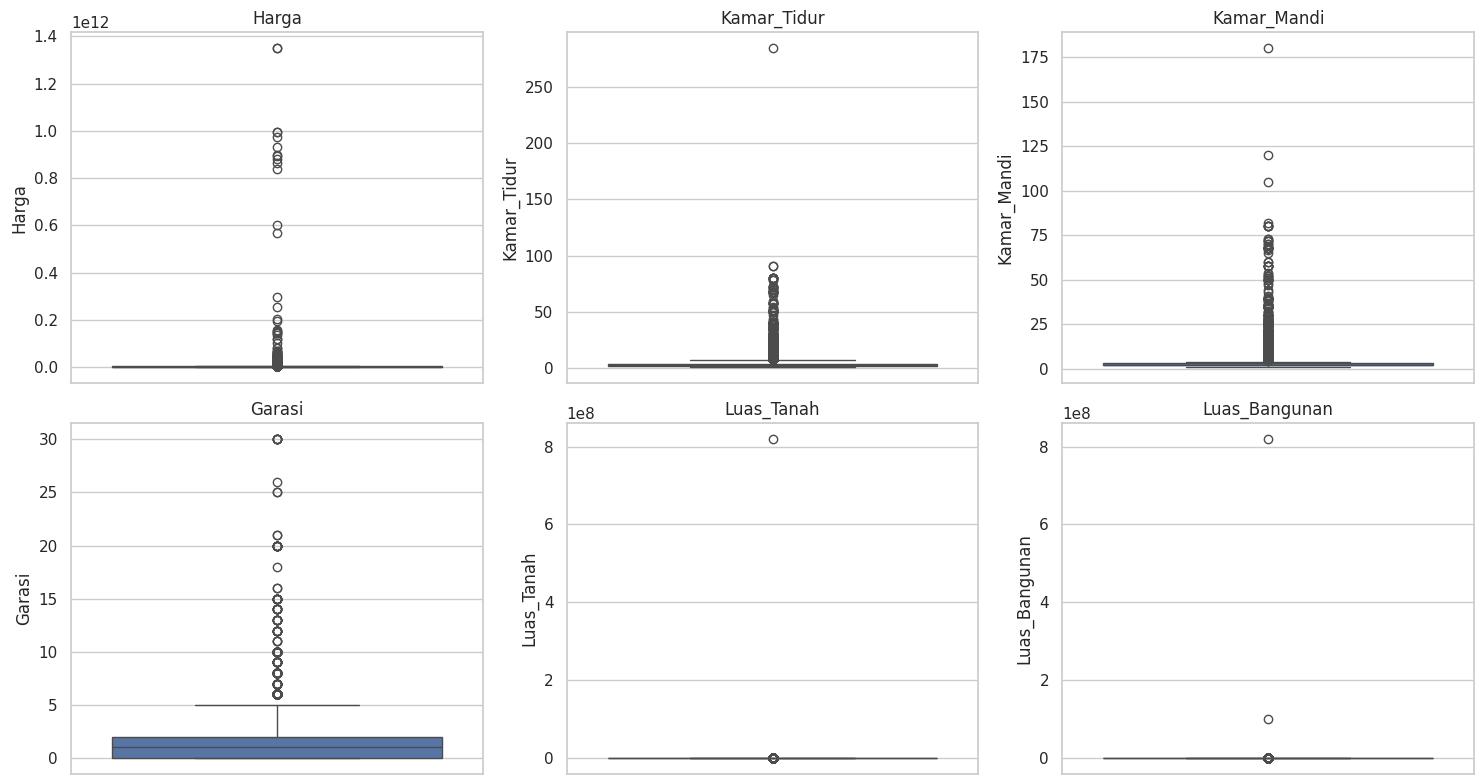

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_cols = ["Harga","Kamar_Tidur","Kamar_Mandi","Garasi","Luas_Tanah","Luas_Bangunan"]
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(y=df_clean[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Boxplot menunjukkan outlier ekstrem pada `Harga` dan `Luas_Bangunan`.

In [16]:
print("=== 5 harga tertinggi (kemungkinan salah satuan Juta/Miliar) ===")
display_cols = ["Harga","Kamar_Tidur","Luas_Tanah","Luas_Bangunan","Kecamatan"]
print(df_clean.nlargest(5, "Harga")[display_cols].to_string(index=False))

print("\n=== 5 harga terendah ===")
print(df_clean.nsmallest(5, "Harga")[display_cols].to_string(index=False))

=== 5 harga tertinggi (kemungkinan salah satuan Juta/Miliar) ===
        Harga  Kamar_Tidur  Luas_Tanah  Luas_Bangunan    Kecamatan
1350000000000           91      101375          14000     Margonda
1350000000000           91      120000          12000     Margonda
 995000000000            2          43             63       Cinere
 995000000000            3          61             95 Pancoran Mas
 975000000000            2         150             50     Sawangan

=== 5 harga terendah ===
 Harga  Kamar_Tidur  Luas_Tanah  Luas_Bangunan Kecamatan
  3500            3         300            150    Cinere
350000            2          55             36  Cinangka
400000            2          60             45   Citayam
414000            2          60             36   Citayam
422000            2          84             36   Citayam


Pemeriksaan outlier menunjukkan kesalahan satuan data. Outlier ditangani dengan **pemangkasan persentil** (1% terendah dan 1% tertinggi) pada setiap kolom numerik.

In [17]:
kolom_untuk_trim = ["Harga","Kamar_Tidur","Kamar_Mandi","Garasi","Luas_Tanah","Luas_Bangunan"]

mask_valid = pd.Series(True, index=df_clean.index)
for col in kolom_untuk_trim:
    batas_bawah, batas_atas = df_clean[col].quantile([0.01, 0.99])
    mask_valid &= df_clean[col].between(batas_bawah, batas_atas)

jumlah_sebelum = len(df_clean)
df_clean = df_clean[mask_valid].reset_index(drop=True)
print(f"Baris sebelum trimming outlier : {jumlah_sebelum:,}")
print(f"Baris setelah trimming outlier : {len(df_clean):,}  (dibuang: {jumlah_sebelum - len(df_clean):,})")

df_clean.describe()

Baris sebelum trimming outlier : 24,833
Baris setelah trimming outlier : 23,303  (dibuang: 1,530)


,Harga,Kamar_Tidur,Kamar_Mandi,Garasi,Luas_Tanah,Luas_Bangunan
count,2.330300e+04,23303.000000,23303.000000,23303.000000,23303.000000,23303.000000
mean,2.215007e+09,3.383341,2.541132,1.104193,179.978930,157.779213
std,2.272973e+09,1.438115,1.432190,0.946356,192.677455,137.174887
min,1.250000e+08,2.000000,1.000000,0.000000,40.000000,35.000000
25%,8.500000e+08,3.000000,2.000000,0.000000,72.000000,70.000000
50%,1.400000e+09,3.000000,2.000000,1.000000,105.000000,110.000000
75%,2.700000e+09,4.000000,3.000000,2.000000,200.000000,200.000000
max,1.850000e+10,18.000000,16.000000,6.000000,1670.000000,1000.000000


### 3.6 Perlakuan terhadap Kolom `Kecamatan`

Kolom `Kecamatan` di-encode menggunakan **One-Hot Encoding**. Area di luar Depok (`Luar Depok`) akan dibuang.

In [18]:
kecamatan_mapping = {
    'Beji': 'Beji', 'Kukusan': 'Beji', 'Tanah Baru': 'Beji', 'Depok I': 'Beji', 'Margonda': 'Beji',
    'Bojong Sari': 'Bojongsari',
    'Cilodong': 'Cilodong', 'Sukatani': 'Cilodong', 'Grand Depok City': 'Cilodong',
    'Cimanggis': 'Cimanggis', 'Tugu': 'Cimanggis', 'Mekarsari': 'Cimanggis', 'Harjamukti': 'Cimanggis',
    'Kelapa Dua': 'Cimanggis', 'Cibubur': 'Cimanggis', 'Kalimanggis': 'Cimanggis',
    'Cinere': 'Cinere', 'Gandul': 'Cinere', 'Pangkalan Jati': 'Cinere',
    'Cipayung': 'Cipayung', 'Citayam': 'Cipayung',
    'Limo': 'Limo', 'Krukut': 'Limo',
    'Pancoran Mas': 'Pancoran Mas', 'Rangkapanjaya': 'Pancoran Mas', 'Babadan': 'Pancoran Mas',
    'Sawangan': 'Sawangan', 'Cinangka': 'Sawangan', 'Pasir Putih': 'Sawangan',
    'Sukmajaya': 'Sukmajaya', 'Tirtajaya': 'Sukmajaya', 'Cisalak': 'Sukmajaya',
    'Depok II': 'Sukmajaya', 'Studio Alam': 'Sukmajaya',
    'Tapos': 'Tapos', 'Cilangkap': 'Tapos',
    'Ciangsana': 'Luar Depok',
}

df_clean["Kecamatan_Resmi"] = df_clean["Kecamatan"].map(kecamatan_mapping).fillna(df_clean["Kecamatan"])

jumlah_sebelum_filter_area = len(df_clean)
df_clean = df_clean[df_clean["Kecamatan_Resmi"] != "Luar Depok"].reset_index(drop=True)
print(f"Baris sebelum menyaring area di luar Depok : {jumlah_sebelum_filter_area:,}")
print(f"Baris setelah menyaring area di luar Depok : {len(df_clean):,}")

print("\nJumlah kategori Kecamatan (nama area pemasaran, dipakai untuk One-Hot Encoding):",
      df_clean["Kecamatan"].nunique())
df_clean["Kecamatan"].value_counts()

Baris sebelum menyaring area di luar Depok : 23,303
Baris setelah menyaring area di luar Depok : 23,292

Jumlah kategori Kecamatan (nama area pemasaran, dipakai untuk One-Hot Encoding): 36


,count
Kecamatan,
Cinere,5084
Sawangan,2752
Cimanggis,1694
Cilodong,1365
Pancoran Mas,1363
Sukmajaya,1206
Beji,954
Limo,913
Cibubur,819


### 3.7 Feature Engineering (Fitur Fisik Rumah)

Fitur turunan baru ditambahkan: `rasio_bangunan_tanah`, `selisih_luas`, `total_kamar` (Kamar Tidur + Kamar Mandi), dan `rasio_km_kt`. Fitur `Harga per m²` tidak digunakan sebagai input untuk menghindari *data leakage*.

In [19]:
df_clean["rasio_bangunan_tanah"] = df_clean["Luas_Bangunan"] / df_clean["Luas_Tanah"]
df_clean["selisih_luas"]         = df_clean["Luas_Tanah"] - df_clean["Luas_Bangunan"]
df_clean["total_kamar"]          = df_clean["Kamar_Tidur"] + df_clean["Kamar_Mandi"]
df_clean["rasio_km_kt"]          = df_clean["Kamar_Mandi"] / df_clean["Kamar_Tidur"]

df_clean.describe()

,Harga,Kamar_Tidur,Kamar_Mandi,Garasi,Luas_Tanah,Luas_Bangunan,rasio_bangunan_tanah,selisih_luas,total_kamar,rasio_km_kt
count,2.329200e+04,23292.000000,23292.000000,23292.000000,23292.000000,23292.000000,23292.000000,23292.000000,23292.000000,23292.000000
mean,2.215269e+09,3.383565,2.541345,1.104027,179.989481,157.800747,1.011865,22.188734,5.924910,0.741509
std,2.273162e+09,1.438285,1.432271,0.946351,192.671762,137.189282,0.461351,125.202955,2.725153,0.250877
min,1.250000e+08,2.000000,1.000000,0.000000,40.000000,35.000000,0.051220,-744.000000,3.000000,0.142857
25%,8.500000e+08,3.000000,2.000000,0.000000,72.000000,70.000000,0.671141,-27.000000,4.000000,0.500000
50%,1.400000e+09,3.000000,2.000000,1.000000,105.000000,110.000000,0.952381,5.000000,5.000000,0.666667
75%,2.700000e+09,4.000000,3.000000,2.000000,200.000000,200.000000,1.265957,36.000000,7.000000,1.000000
max,1.850000e+10,18.000000,16.000000,6.000000,1670.000000,1000.000000,13.200000,1467.000000,32.000000,5.500000


### 3.8 Analisis Korelasi Antar Fitur Numerik (Heatmap)

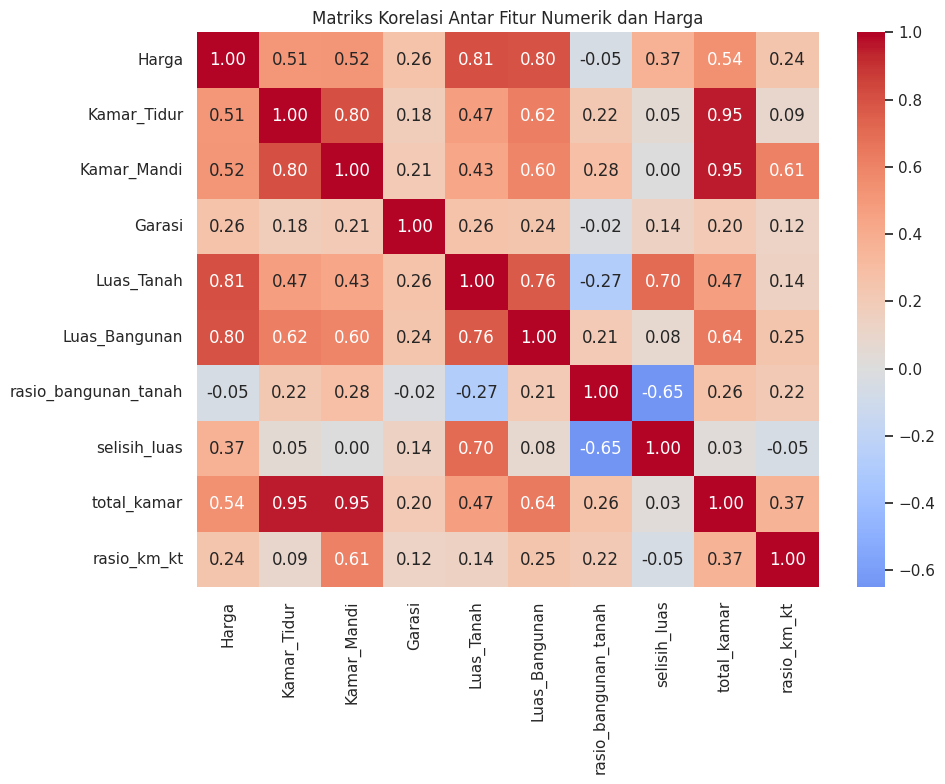

In [20]:
kolom_korelasi = ["Harga","Kamar_Tidur","Kamar_Mandi","Garasi","Luas_Tanah","Luas_Bangunan",
                   "rasio_bangunan_tanah","selisih_luas","total_kamar","rasio_km_kt"]

matriks_korelasi = df_clean[kolom_korelasi].corr()

fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(matriks_korelasi, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriks Korelasi Antar Fitur Numerik dan Harga")
plt.tight_layout()
plt.show()

`total_kamar`, `selisih_luas`, dan `rasio_bangunan_tanah` berkorelasi kuat dengan fitur asalnya. Model berbasis pohon tidak terpengaruh multikolinearitas, namun Ridge Regression perlu diwaspadai.

In [21]:
### 3.9 Dataset Final Setelah Data Preparation

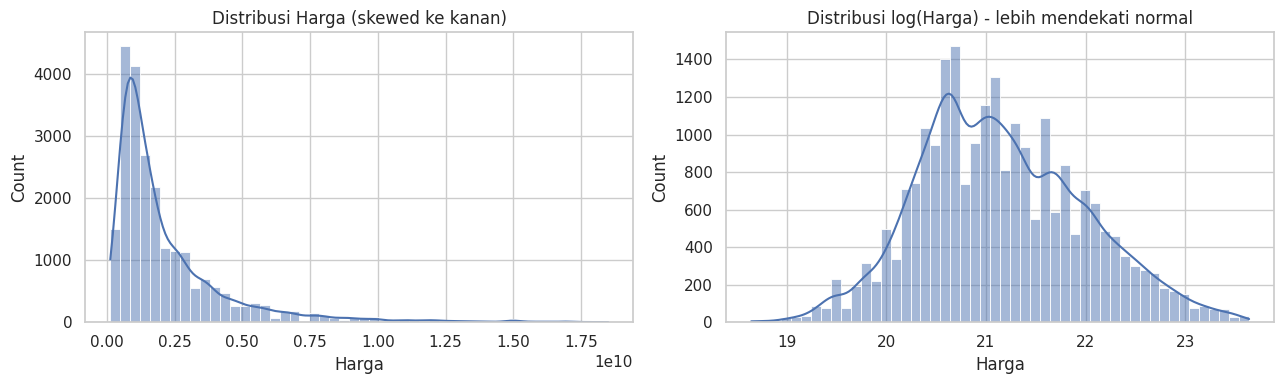

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
sns.histplot(df_clean["Harga"], bins=50, ax=axes[0], kde=True)
axes[0].set_title("Distribusi Harga (skewed ke kanan)")
sns.histplot(np.log1p(df_clean["Harga"]), bins=50, ax=axes[1], kde=True)
axes[1].set_title("Distribusi log(Harga) - lebih mendekati normal")
plt.tight_layout()
plt.show()

`Harga` skewed ke kanan. Target tetap `Harga` asli untuk interpretasi bisnis; model pohon tidak mensyaratkan distribusi normal, dan Ridge tetap bekerja karena fitur sudah distandardisasi.

## 4. Modeling

### 4.1 Pembagian Data Train/Test

Data dibagi 80% latih, 20% uji, dengan `random_state=SEED`.

In [23]:
from sklearn.model_selection import train_test_split

# Convert relevant columns in df_variabel_tambahan to numeric
numeric_cols_variabel = ["jml_faskes", "jml_stasiun", "jml_mall", "jml_sekolah_pt", "kepadatan"]
for col in numeric_cols_variabel:
    df_variabel_tambahan[col] = pd.to_numeric(df_variabel_tambahan[col], errors='coerce')

# Merge df_clean with df_variabel_tambahan
df_processed = pd.merge(
    df_clean,
    df_variabel_tambahan,
    left_on="Kecamatan_Resmi",
    right_on="kec",
    how="left"
)
# Drop the redundant 'kec' column from the merge
df_processed = df_processed.drop(columns=["kec"])

X = df_processed.drop(columns=["Harga", "Kecamatan_Resmi"])
y = df_processed["Harga"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (18633, 15)  Test: (4659, 15)


### 4.2 Preprocessing Pipeline

Satu pipeline preprocessing tunggal (dengan `StandardScaler` dan `OneHotEncoder`) digunakan untuk semua model, termasuk model berbasis pohon, agar konsisten dan adil untuk Ridge Regression dalam Stacking Ensemble.

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Menambahkan variabel spasial eksternal ke dalam fitur numerik
fitur_numerik    = ["Kamar_Tidur","Kamar_Mandi","Garasi","Luas_Tanah","Luas_Bangunan",
                     "rasio_bangunan_tanah","selisih_luas","total_kamar","rasio_km_kt",
                     "jml_faskes", "jml_stasiun", "jml_mall", "jml_sekolah_pt", "kepadatan"]
fitur_kategorikal = ["Kecamatan"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), fitur_numerik),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), fitur_kategorikal)
])

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

def evaluasi(y_true, y_pred, nama):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"{nama:28s} | MAE: Rp {mae:>15,.0f} | RMSE: Rp {rmse:>15,.0f} | R2: {r2:.4f} | MAPE: {mape:.2f}%")
    return {"model": nama, "MAE": mae, "RMSE": rmse, "R2": r2, "MAPE(%)": mape}

### 4.3 Baseline Model Default

Empat model (Linear Regression, Random Forest, XGBoost, LightGBM) dilatih dengan parameter default sebagai patokan dasar. Fitur `Harga_per_Luas` (penyebab *data leakage* di versi lama) sudah tidak ada.

In [26]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, StackingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

def buat_model_default():
    '''Konstruktor model default -- dipanggil ulang tiap kali agar tidak ada state yang terbawa antar-tahap.'''
    return {
        "Linear Regression": LinearRegression(),
        "Random Forest":     RandomForestRegressor(random_state=SEED, n_jobs=-1),
        "XGBoost":            XGBRegressor(random_state=SEED, n_jobs=-1, tree_method="hist"),
        "LightGBM":           LGBMRegressor(random_state=SEED, n_jobs=-1, verbosity=-1),
    }

hasil_baseline = []
model_terlatih_baseline = {}

for nama_model, model in buat_model_default().items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    hasil_baseline.append(evaluasi(y_test, pred, f"{nama_model} (Default)"))
    model_terlatih_baseline[nama_model] = pipe

baseline_df = pd.DataFrame(hasil_baseline)
baseline_df

Linear Regression (Default)  | MAE: Rp     603,583,746 | RMSE: Rp   1,161,791,838 | R2: 0.7513 | MAPE: 29.74%
Random Forest (Default)      | MAE: Rp     440,702,438 | RMSE: Rp     911,892,209 | R2: 0.8468 | MAPE: 22.13%
XGBoost (Default)            | MAE: Rp     485,756,544 | RMSE: Rp     967,816,051 | R2: 0.8274 | MAPE: 24.45%
LightGBM (Default)           | MAE: Rp     505,097,720 | RMSE: Rp     975,168,897 | R2: 0.8248 | MAPE: 25.50%


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,MAE,RMSE,R2,MAPE(%)
0,Linear Regression (Default),6.035837e+08,1.161792e+09,0.751293,29.744137
1,Random Forest (Default),4.407024e+08,9.118922e+08,0.846779,22.125688
2,XGBoost (Default),4.857565e+08,9.678161e+08,0.827410,24.447076
3,LightGBM (Default),5.050977e+08,9.751689e+08,0.824777,25.498573


### 4.4 Stacking Ensemble sesuai Paper Acuan

Menerapkan `StackingRegressor`:

- **Pembelajar dasar**: Random Forest, `HistGradientBoostingRegressor`, Ridge Regression.
- **Pembelajar meta**: Ridge Regression, dilatih di atas prediksi *out-of-fold* (`cv=5`).

Semua estimator menggunakan `random_state=SEED`.

In [27]:
base_estimators_stacking = [
    ("rf",    RandomForestRegressor(random_state=SEED, n_jobs=-1)),
    ("hgb",   HistGradientBoostingRegressor(random_state=SEED)),
    ("ridge", Ridge(random_state=SEED)),
]

stacking_model = StackingRegressor(
    estimators=base_estimators_stacking,
    final_estimator=Ridge(random_state=SEED),
    cv=5,
    n_jobs=-1,
)

pipe_stacking = Pipeline([("preprocessor", preprocessor), ("model", stacking_model)])
pipe_stacking.fit(X_train, y_train)
pred_stacking = pipe_stacking.predict(X_test)

hasil_baseline.append(evaluasi(y_test, pred_stacking, "Stacking Ensemble (Default)"))
model_terlatih_baseline["Stacking Ensemble"] = pipe_stacking

baseline_df = pd.DataFrame(hasil_baseline)
baseline_df

Stacking Ensemble (Default)  | MAE: Rp     443,778,589 | RMSE: Rp     912,683,566 | R2: 0.8465 | MAPE: 22.02%


,model,MAE,RMSE,R2,MAPE(%)
0,Linear Regression (Default),6.035837e+08,1.161792e+09,0.751293,29.744137
1,Random Forest (Default),4.407024e+08,9.118922e+08,0.846779,22.125688
2,XGBoost (Default),4.857565e+08,9.678161e+08,0.827410,24.447076
3,LightGBM (Default),5.050977e+08,9.751689e+08,0.824777,25.498573
4,Stacking Ensemble (Default),4.437786e+08,9.126836e+08,0.846513,22.016424


### 4.5 Validasi Silang 5-Fold: Perbandingan Adil Antar Model

Semua model dievaluasi ulang menggunakan **5-fold cross-validation** (`KFold(n_splits=5, shuffle=True, random_state=SEED)`) untuk perbandingan yang adil.

In [28]:
from sklearn.model_selection import cross_val_score, KFold

cv_5fold = KFold(n_splits=5, shuffle=True, random_state=SEED)
hasil_cv = []

model_untuk_cv = {**buat_model_default(), "Stacking Ensemble": stacking_model}

for nama_model, model in model_untuk_cv.items():
    pipe_cv = Pipeline([("preprocessor", preprocessor), ("model", model)])
    r2_scores   = cross_val_score(pipe_cv, X, y, cv=cv_5fold, scoring="r2", n_jobs=-1)
    mae_scores  = -cross_val_score(pipe_cv, X, y, cv=cv_5fold, scoring="neg_mean_absolute_error", n_jobs=-1)
    rmse_scores = -cross_val_score(pipe_cv, X, y, cv=cv_5fold, scoring="neg_root_mean_squared_error", n_jobs=-1)
    mape_scores = -cross_val_score(pipe_cv, X, y, cv=cv_5fold, scoring="neg_mean_absolute_percentage_error", n_jobs=-1) * 100
    hasil_cv.append({
        "model": nama_model,
        "R2_mean": r2_scores.mean(), "R2_std": r2_scores.std(),
        "MAE_mean": mae_scores.mean(), "RMSE_mean": rmse_scores.mean(),
        "MAPE_mean": mape_scores.mean(), "MAPE_std": mape_scores.std(),
    })
    print(f"{nama_model:20s} | R2: {r2_scores.mean():.4f} (+/- {r2_scores.std():.4f}) "
          f"| MAE: Rp {mae_scores.mean():,.0f} | RMSE: Rp {rmse_scores.mean():,.0f} "
          f"| MAPE: {mape_scores.mean():.2f}%")

cv_df = pd.DataFrame(hasil_cv).sort_values("R2_mean", ascending=False).reset_index(drop=True)
cv_df

Linear Regression    | R2: 0.7603 (+/- 0.0140) | MAE: Rp 595,516,081 | RMSE: Rp 1,112,150,388 | MAPE: 30.40%
Random Forest        | R2: 0.8459 (+/- 0.0108) | MAE: Rp 442,287,803 | RMSE: Rp 891,528,185 | MAPE: 22.92%
XGBoost              | R2: 0.8280 (+/- 0.0089) | MAE: Rp 485,574,771 | RMSE: Rp 942,122,266 | MAPE: 24.82%


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


LightGBM             | R2: 0.8294 (+/- 0.0119) | MAE: Rp 501,396,984 | RMSE: Rp 938,095,838 | MAPE: 26.15%
Stacking Ensemble    | R2: 0.8464 (+/- 0.0110) | MAE: Rp 446,558,347 | RMSE: Rp 890,080,144 | MAPE: 22.90%


,model,R2_mean,R2_std,MAE_mean,RMSE_mean,MAPE_mean,MAPE_std
0,Stacking Ensemble,0.846413,0.010965,4.465583e+08,8.900801e+08,22.902800,0.355426
1,Random Forest,0.845906,0.010834,4.422878e+08,8.915282e+08,22.915224,0.451178
2,LightGBM,0.829413,0.011880,5.013970e+08,9.380958e+08,26.148974,0.396214
3,XGBoost,0.828005,0.008926,4.855748e+08,9.421223e+08,24.818033,0.312888
4,Linear Regression,0.760350,0.014045,5.955161e+08,1.112150e+09,30.398756,0.394571


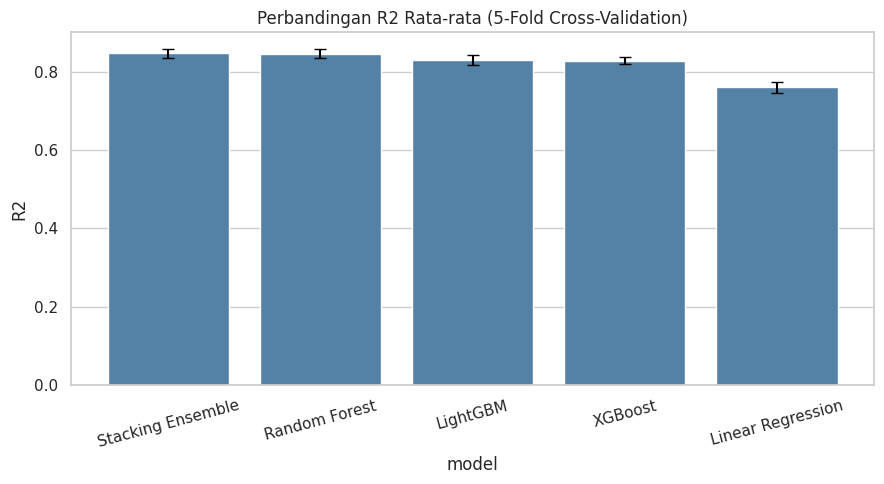

In [29]:
fig, ax = plt.subplots(figsize=(9,5))
sns.barplot(data=cv_df, x="model", y="R2_mean", ax=ax, color="steelblue")
ax.errorbar(x=np.arange(len(cv_df)), y=cv_df["R2_mean"], yerr=cv_df["R2_std"],
            fmt="none", ecolor="black", capsize=4)
ax.set_title("Perbandingan R2 Rata-rata (5-Fold Cross-Validation)")
ax.set_ylabel("R2")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Jika Stacking Ensemble menunjukkan R² rata-rata lebih tinggi, ini mengonfirmasi temuan paper acuan.

### 4.6 Seleksi Model Jagoan

Semua model akan dituning terlebih dahulu. Pemilihan model terbaik dilakukan **SETELAH** tuning selesai, berdasarkan R² dan MAPE.

In [30]:
ranking_cv = cv_df.sort_values(["R2_mean","MAE_mean"], ascending=[False, True]).reset_index(drop=True)

# Memasukkan metrik MAPE ke dalam tabel perbandingan dengan melakukan evaluasi pada data test menggunakan model default
hasil_default_test = []
for nama_model, model_pipe in model_terlatih_baseline.items():
    pred_temp = model_pipe.predict(X_test)
    mae_temp = mean_absolute_error(y_test, pred_temp)
    rmse_temp = mean_squared_error(y_test, pred_temp) ** 0.5
    r2_temp = r2_score(y_test, pred_temp)
    mape_temp = mean_absolute_percentage_error(y_test, pred_temp) * 100
    hasil_default_test.append({
        "model": nama_model,
        "R2_Test": r2_temp,
        "MAE_Test": mae_temp,
        "RMSE_Test": rmse_temp,
        "MAPE_Test(%)": mape_temp
    })

default_test_df = pd.DataFrame(hasil_default_test)
ranking_seleksi = ranking_cv.merge(default_test_df, on="model")

print("=== Ringkasan & Seleksi Model (Urutan Berdasarkan R2 CV) ===")
display(ranking_seleksi[["model", "R2_mean", "MAE_mean", "RMSE_mean", "MAPE_Test(%)"]])

# Sekarang, semua model akan dimasukkan ke dalam daftar tuning
model_terpilih = ranking_seleksi["model"].tolist()
print(f"\n Seluruh model berikut akan masuk ke tahap tuning: {model_terpilih}")

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


=== Ringkasan & Seleksi Model (Urutan Berdasarkan R2 CV) ===


,model,R2_mean,MAE_mean,RMSE_mean,MAPE_Test(%)
0,Stacking Ensemble,0.846413,4.465583e+08,8.900801e+08,22.016424
1,Random Forest,0.845906,4.422878e+08,8.915282e+08,22.125688
2,LightGBM,0.829413,5.013970e+08,9.380958e+08,25.498573
3,XGBoost,0.828005,4.855748e+08,9.421223e+08,24.447076
4,Linear Regression,0.760350,5.955161e+08,1.112150e+09,29.744137



 Seluruh model berikut akan masuk ke tahap tuning: ['Stacking Ensemble', 'Random Forest', 'LightGBM', 'XGBoost', 'Linear Regression']


### 4.7 Tuning Hyperparameter Final (Hanya untuk Model Terpilih)

Pencarian hyperparameter dilakukan dengan Optuna melalui *5-fold cross-validation* pada `X_train`/`y_train`, meminimalkan MAE. Tuning Stacking Ensemble jauh lebih mahal secara komputasi.

In [31]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
N_TRIALS = 30

def objective_rf(trial, X_tr, y_tr):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 1.0]),
        "max_samples": trial.suggest_float("max_samples", 0.5, 1.0),
    }
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=SEED, n_jobs=-1, **params)),
    ])
    score = cross_val_score(pipe, X_tr, y_tr, cv=5, scoring="neg_mean_absolute_error", n_jobs=1)
    return -score.mean()

def objective_xgb(trial, X_tr, y_tr):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
    }
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(random_state=SEED, n_jobs=-1, tree_method="hist", **params)),
    ])
    score = cross_val_score(pipe, X_tr, y_tr, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1)
    return -score.mean()

def objective_lgbm(trial, X_tr, y_tr):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
    }
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", LGBMRegressor(random_state=SEED, n_jobs=-1, verbosity=-1, **params)),
    ])
    score = cross_val_score(pipe, X_tr, y_tr, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1)
    return -score.mean()

def objective_linear(trial, X_tr, y_tr):
    # Regresi Linear tidak punya hyperparameter untuk di-tuning; disertakan hanya
    # agar seluruh model kandidat dapat diperlakukan melalui alur OBJECTIVE_MAP yang sama.
    pipe = Pipeline([("preprocessor", preprocessor), ("model", LinearRegression())])
    score = cross_val_score(pipe, X_tr, y_tr, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1)
    return -score.mean()

def objective_stacking(trial, X_tr, y_tr):
    params = {
        "rf_n_estimators": trial.suggest_int("rf_n_estimators", 100, 400),
        "rf_max_depth": trial.suggest_int("rf_max_depth", 5, 30),
        "hgb_learning_rate": trial.suggest_float("hgb_learning_rate", 0.01, 0.3, log=True),
        "hgb_max_iter": trial.suggest_int("hgb_max_iter", 100, 400),
        "ridge_alpha_base": trial.suggest_float("ridge_alpha_base", 0.1, 50, log=True),
        "meta_alpha": trial.suggest_float("meta_alpha", 0.1, 50, log=True),
    }
    base_estimators = [
        ("rf",    RandomForestRegressor(n_estimators=params["rf_n_estimators"],
                                         max_depth=params["rf_max_depth"],
                                         random_state=SEED, n_jobs=-1)),
        ("hgb",   HistGradientBoostingRegressor(learning_rate=params["hgb_learning_rate"],
                                                 max_iter=params["hgb_max_iter"],
                                                 random_state=SEED)),
        ("ridge", Ridge(alpha=params["ridge_alpha_base"], random_state=SEED)),
    ]
    model = StackingRegressor(
        estimators=base_estimators,
        final_estimator=Ridge(alpha=params["meta_alpha"], random_state=SEED),
        cv=5, n_jobs=-1,
    )
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    score = cross_val_score(pipe, X_tr, y_tr, cv=5, scoring="neg_mean_absolute_error", n_jobs=1)
    return -score.mean()

def bangun_estimator_final(nama_model, best_params):
    if nama_model == "Random Forest":
        return RandomForestRegressor(random_state=SEED, n_jobs=-1, **best_params)
    elif nama_model == "XGBoost":
        return XGBRegressor(random_state=SEED, n_jobs=-1, tree_method="hist", **best_params)
    elif nama_model == "LightGBM":
        return LGBMRegressor(random_state=SEED, n_jobs=-1, verbosity=-1, **best_params)
    elif nama_model == "Linear Regression":
        return LinearRegression()
    elif nama_model == "Stacking Ensemble":
        base_estimators = [
            ("rf",    RandomForestRegressor(n_estimators=best_params["rf_n_estimators"],
                                             max_depth=best_params["rf_max_depth"],
                                             random_state=SEED, n_jobs=-1)),
            ("hgb",   HistGradientBoostingRegressor(learning_rate=best_params["hgb_learning_rate"],
                                                     max_iter=best_params["hgb_max_iter"],
                                                     random_state=SEED)),
            ("ridge", Ridge(alpha=best_params["ridge_alpha_base"], random_state=SEED)),
        ]
        return StackingRegressor(
            estimators=base_estimators,
            final_estimator=Ridge(alpha=best_params["meta_alpha"], random_state=SEED),
            cv=5, n_jobs=-1,
        )
    raise ValueError(f"Model tidak dikenal: {nama_model}")

OBJECTIVE_MAP = {
    "Random Forest": objective_rf,
    "XGBoost": objective_xgb,
    "LightGBM": objective_lgbm,
    "Linear Regression": objective_linear,
    "Stacking Ensemble": objective_stacking,
}

In [32]:
import gc
import time

# Catatan: budget di bawah berlaku PER MODEL. Karena sekarang menuning seluruh
# model (termasuk Stacking Ensemble yang mahal), total waktu ≈ WAKTU_TUNING_DETIK x jumlah model.
# Turunkan nilainya (mis. 300) kalau waktu di Colab terbatas.
WAKTU_TUNING_DETIK = 300

hasil_tuning = []
tuned_pipelines = {}
tuned_predictions = {}
studies = {}
waktu_tuning_aktual = {}

In [33]:
for nama_model in model_terpilih:
    print(f"=== Tuning {nama_model} (budget {WAKTU_TUNING_DETIK} detik) ===")

    sampler = optuna.samplers.TPESampler(seed=SEED)
    study = optuna.create_study(direction="minimize", sampler=sampler)

    waktu_mulai = time.time()
    study.optimize(
        lambda trial: OBJECTIVE_MAP[nama_model](trial, X_train, y_train),
        timeout=WAKTU_TUNING_DETIK,
        n_jobs=1,
        gc_after_trial=True,
        show_progress_bar=True
    )
    waktu_terpakai = time.time() - waktu_mulai

    print(f"{nama_model} menyelesaikan {len(study.trials)} trial dalam {waktu_terpakai:.0f} detik")
    print(f"Best params ({nama_model}):", study.best_params)
    print(f"Best CV MAE ({nama_model}):", study.best_value)

    best_pipe_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", bangun_estimator_final(nama_model, study.best_params)),
    ])
    best_pipe_model.fit(X_train, y_train)
    pred_model = best_pipe_model.predict(X_test)

    studies[nama_model] = study
    tuned_pipelines[nama_model] = best_pipe_model
    tuned_predictions[nama_model] = pred_model
    waktu_tuning_aktual[nama_model] = {"detik": waktu_terpakai, "jumlah_trial": len(study.trials)}
    hasil_tuning.append(evaluasi(y_test, pred_model, f"{nama_model} (Tuned)"))

    del study, best_pipe_model, sampler
    gc.collect()

hasil_tuning_df = pd.DataFrame(hasil_tuning)
hasil_tuning_df

=== Tuning Stacking Ensemble (budget 300 detik) ===


   0%|          | 00:00/05:00

Stacking Ensemble menyelesaikan 1 trial dalam 544 detik
Best params (Stacking Ensemble): {'rf_n_estimators': 212, 'rf_max_depth': 29, 'hgb_learning_rate': 0.1205712628744377, 'hgb_max_iter': 280, 'ridge_alpha_base': 0.26368755339723043, 'meta_alpha': 0.26364803038431645}
Best CV MAE (Stacking Ensemble): 456442136.45537806
Stacking Ensemble (Tuned)    | MAE: Rp     440,860,332 | RMSE: Rp     910,507,015 | R2: 0.8472 | MAPE: 21.88%
=== Tuning Random Forest (budget 300 detik) ===


   0%|          | 00:00/05:00

Random Forest menyelesaikan 7 trial dalam 386 detik
Best params (Random Forest): {'n_estimators': 339, 'max_depth': 28, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_samples': 0.9143687545759647}
Best CV MAE (Random Forest): 452492194.29726374
Random Forest (Tuned)        | MAE: Rp     439,740,812 | RMSE: Rp     906,058,974 | R2: 0.8487 | MAPE: 21.99%
=== Tuning LightGBM (budget 300 detik) ===


...

   0%|          | 00:00/05:00

XGBoost menyelesaikan 27 trial dalam 301 detik
Best params (XGBoost): {'n_estimators': 321, 'max_depth': 12, 'learning_rate': 0.03232365277671205, 'subsample': 0.8211034662621066, 'colsample_bytree': 0.5969026486473856, 'min_child_weight': 1, 'reg_lambda': 0.0012304356349559546}
Best CV MAE (XGBoost): 451312659.2
XGBoost (Tuned)              | MAE: Rp     437,993,632 | RMSE: Rp     907,252,510 | R2: 0.8483 | MAPE: 21.94%
=== Tuning Linear Regression (budget 300 detik) ===


   0%|          | 00:00/05:00

Linear Regression menyelesaikan 652 trial dalam 300 detik
Best params (Linear Regression): {}
Best CV MAE (Linear Regression): 592996376.9701405
Linear Regression (Tuned)    | MAE: Rp     603,583,746 | RMSE: Rp   1,161,791,838 | R2: 0.7513 | MAPE: 29.74%


,model,MAE,RMSE,R2,MAPE(%)
0,Stacking Ensemble (Tuned),4.408603e+08,9.105070e+08,0.847244,21.877331
1,Random Forest (Tuned),4.397408e+08,9.060590e+08,0.848733,21.987073
2,LightGBM (Tuned),4.464814e+08,9.151981e+08,0.845666,22.376566
3,XGBoost (Tuned),4.379936e+08,9.072525e+08,0.848334,21.944466
4,Linear Regression (Tuned),6.035837e+08,1.161792e+09,0.751293,29.744137


### 4.8 Ringkasan Proses Tuning

Ringkasan hasil tuning dan evaluasi model pada data test.

In [34]:
print("=== Ringkasan Hasil Tuning (CV MAE & Profil Waktu) ===")
ringkasan_tuning = pd.DataFrame([
    {
        "model": nama,
        "Best CV MAE": studies[nama].best_value,
        "Jumlah Trial": waktu_tuning_aktual[nama]["jumlah_trial"],
        "Waktu Tuning (detik)": round(waktu_tuning_aktual[nama]["detik"], 1),
    }
    for nama in model_terpilih if nama in studies and nama in waktu_tuning_aktual
]).sort_values("Best CV MAE").reset_index(drop=True)
display(ringkasan_tuning)

print("\n=== Hasil Evaluasi Model pada Data Test ===")
hasil_tuning_df = pd.DataFrame(hasil_tuning)
display(hasil_tuning_df)

=== Ringkasan Hasil Tuning (CV MAE & Profil Waktu) ===


,model,Best CV MAE,Jumlah Trial,Waktu Tuning (detik)
0,XGBoost,4.513127e+08,27,301.2
1,Random Forest,4.524922e+08,7,385.8
2,Stacking Ensemble,4.564421e+08,1,543.7
3,LightGBM,4.576483e+08,18,313.5
4,Linear Regression,5.929964e+08,652,300.4



=== Hasil Evaluasi Model pada Data Test ===


,model,MAE,RMSE,R2,MAPE(%)
0,Stacking Ensemble (Tuned),4.408603e+08,9.105070e+08,0.847244,21.877331
1,Random Forest (Tuned),4.397408e+08,9.060590e+08,0.848733,21.987073
2,LightGBM (Tuned),4.464814e+08,9.151981e+08,0.845666,22.376566
3,XGBoost (Tuned),4.379936e+08,9.072525e+08,0.848334,21.944466
4,Linear Regression (Tuned),6.035837e+08,1.161792e+09,0.751293,29.744137


## 5. Evaluation

In [35]:
ringkasan_lengkap = pd.concat([
    baseline_df.assign(tahap="1. Default (single split)"),
    cv_df.rename(columns={"R2_mean":"R2","MAE_mean":"MAE","RMSE_mean":"RMSE","MAPE_mean":"MAPE(%)"})
         [["model","MAE","RMSE","R2","MAPE(%)"]]
         .assign(tahap="2. Rata-rata 5-Fold CV"),
    hasil_tuning_df.assign(tahap="3. Tuned (Optuna)"),
], ignore_index=True)

ringkasan_lengkap = ringkasan_lengkap[["tahap","model","MAE","RMSE","R2","MAPE(%)"]].sort_values(
    ["tahap","R2"], ascending=[True, False])
ringkasan_lengkap

,tahap,model,MAE,RMSE,R2,MAPE(%)
1,1. Default (single split),Random Forest (Default),4.407024e+08,9.118922e+08,0.846779,22.125688
4,1. Default (single split),Stacking Ensemble (Default),4.437786e+08,9.126836e+08,0.846513,22.016424
2,1. Default (single split),XGBoost (Default),4.857565e+08,9.678161e+08,0.827410,24.447076
3,1. Default (single split),LightGBM (Default),5.050977e+08,9.751689e+08,0.824777,25.498573
0,1. Default (single split),Linear Regression (Default),6.035837e+08,1.161792e+09,0.751293,29.744137
5,2. Rata-rata 5-Fold CV,Stacking Ensemble,4.465583e+08,8.900801e+08,0.846413,22.902800
6,2. Rata-rata 5-Fold CV,Random Forest,4.422878e+08,8.915282e+08,0.845906,22.915224
7,2. Rata-rata 5-Fold CV,LightGBM,5.013970e+08,9.380958e+08,0.829413,26.148974
8,2. Rata-rata 5-Fold CV,XGBoost,4.855748e+08,9.421223e+08,0.828005,24.818033
9,2. Rata-rata 5-Fold CV,Linear Regression,5.955161e+08,1.112150e+09,0.760350,30.398756


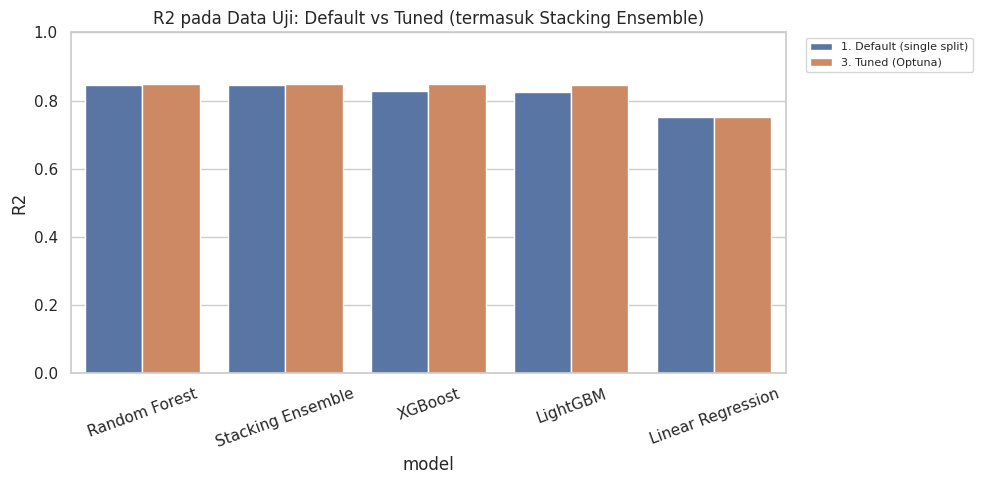

In [36]:
fig, ax = plt.subplots(figsize=(10,5))
plot_df = ringkasan_lengkap[ringkasan_lengkap["tahap"] != "2. Rata-rata 5-Fold CV"].copy()
plot_df["model"] = plot_df["model"].str.replace(r" \((Default|Tuned)\)", "", regex=True)
sns.barplot(data=plot_df, x="model", y="R2", hue="tahap", ax=ax)
ax.set_title("R2 pada Data Uji: Default vs Tuned (termasuk Stacking Ensemble)")
ax.set_ylim(0,1)
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### 5.2 Pemilihan Model Terbaik untuk Analisis Lanjutan

Model dengan MAPE terendah setelah tuning dipilih sebagai model final. Kode ini mendukung model pohon tunggal atau Stacking Ensemble.

In [37]:
nama_model_terbaik = hasil_tuning_df.sort_values(
    ["MAPE(%)", "R2"], ascending=[True, False]
).iloc[0]["model"].replace(" (Tuned)", "")
best_pipe = tuned_pipelines[nama_model_terbaik]
pred_terbaik = tuned_predictions[nama_model_terbaik]
best_model_is_tree = hasattr(best_pipe.named_steps["model"], "feature_importances_")

print("Ranking seluruh model tuned (MAPE = kriteria utama, R2 = tie-breaker):")
print(hasil_tuning_df.sort_values(["MAPE(%)","R2"], ascending=[True, False])
      [["model","R2","MAPE(%)","MAE","RMSE"]].to_string(index=False))
print("\nModel dengan performa terbaik setelah tuning (untuk analisis lanjutan):", nama_model_terbaik)
print("Apakah model berbasis pohon tunggal (punya feature_importances_)?      ", best_model_is_tree)

Ranking seluruh model tuned (MAPE = kriteria utama, R2 = tie-breaker):
                    model       R2   MAPE(%)          MAE         RMSE
Stacking Ensemble (Tuned) 0.847244 21.877331 4.408603e+08 9.105070e+08
          XGBoost (Tuned) 0.848334 21.944466 4.379936e+08 9.072525e+08
    Random Forest (Tuned) 0.848733 21.987073 4.397408e+08 9.060590e+08
         LightGBM (Tuned) 0.845666 22.376566 4.464814e+08 9.151981e+08
Linear Regression (Tuned) 0.751293 29.744137 6.035837e+08 1.161792e+09

Model dengan performa terbaik setelah tuning (untuk analisis lanjutan): Stacking Ensemble
Apakah model berbasis pohon tunggal (punya feature_importances_)?       False


### 5.2b Eksperimen Tambahan: Transformasi Log pada Target

Sebagai eksperimen lanjutan (lihat Section 6.3 poin 5), model terbaik yang terpilih dilatih ulang
dengan target `log1p(Harga)` menggunakan `TransformedTargetRegressor`, agar training terjadi di
ruang log namun `predict()` tetap otomatis mengembalikan nilai dalam Rupiah (`expm1`). Hasilnya
dibandingkan langsung dengan versi skala asli untuk melihat apakah MAPE membaik.

In [38]:
from sklearn.compose import TransformedTargetRegressor

# Bangun ulang model dengan konfigurasi TERBAIK yang sama persis (hasil tuning Optuna),
# lalu bungkus dengan TransformedTargetRegressor agar target dilatih dalam skala log1p.
estimator_terbaik = bangun_estimator_final(nama_model_terbaik, studies[nama_model_terbaik].best_params)

pipe_log = TransformedTargetRegressor(
    regressor=Pipeline([("preprocessor", preprocessor), ("model", estimator_terbaik)]),
    func=np.log1p,
    inverse_func=np.expm1,
)
pipe_log.fit(X_train, y_train)
pred_log = pipe_log.predict(X_test)

# Cek keamanan: pastikan tidak ada nilai meledak/tak terhingga akibat expm1
jumlah_invalid = (~np.isfinite(pred_log)).sum()
print(f"Jumlah prediksi tidak valid (inf/NaN) setelah expm1: {jumlah_invalid}")

hasil_log_vs_nonlog = pd.DataFrame([
    evaluasi(y_test, pred_terbaik, f"{nama_model_terbaik} (Tuned, skala asli)"),
    evaluasi(y_test, pred_log,     f"{nama_model_terbaik} (Tuned, target log1p)"),
])
hasil_log_vs_nonlog

Jumlah prediksi tidak valid (inf/NaN) setelah expm1: 0
Stacking Ensemble (Tuned, skala asli) | MAE: Rp     440,860,332 | RMSE: Rp     910,507,015 | R2: 0.8472 | MAPE: 21.88%
Stacking Ensemble (Tuned, target log1p) | MAE: Rp     444,657,662 | RMSE: Rp     921,882,099 | R2: 0.8434 | MAPE: 20.80%


,model,MAE,RMSE,R2,MAPE(%)
0,"Stacking Ensemble (Tuned, skala asli)",4.408603e+08,9.105070e+08,0.847244,21.877331
1,"Stacking Ensemble (Tuned, target log1p)",4.446577e+08,9.218821e+08,0.843404,20.799973


In [39]:
from sklearn.model_selection import cross_validate

scoring = {"r2": "r2", "mae": "neg_mean_absolute_error",
           "rmse": "neg_root_mean_squared_error", "mape": "neg_mean_absolute_percentage_error"}

pipe_log_cv = TransformedTargetRegressor(
    regressor=Pipeline([("preprocessor", preprocessor),
                         ("model", bangun_estimator_final(nama_model_terbaik, studies[nama_model_terbaik].best_params))]),
    func=np.log1p, inverse_func=np.expm1,
)

hasil_cv_log = cross_validate(pipe_log_cv, X, y, cv=cv_5fold, scoring=scoring, n_jobs=-1)

print(f"{nama_model_terbaik} (target log1p) — 5-Fold CV:")
print(f"  R2:   {hasil_cv_log['test_r2'].mean():.4f} (+/- {hasil_cv_log['test_r2'].std():.4f})")
print(f"  MAPE: {-hasil_cv_log['test_mape'].mean()*100:.2f}%  (+/- {hasil_cv_log['test_mape'].std()*100:.2f})")
print(f"  MAE:  Rp {-hasil_cv_log['test_mae'].mean():,.0f}")
print(f"  RMSE: Rp {-hasil_cv_log['test_rmse'].mean():,.0f}")

baris_cv_asli = cv_df[cv_df["model"] == nama_model_terbaik].iloc[0]
print(f"\n(Pembanding) {nama_model_terbaik} (skala asli) — 5-Fold CV:")
print(f"  R2: {baris_cv_asli['R2_mean']:.4f}   MAPE: {baris_cv_asli['MAPE_mean']:.2f}%")

/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Stacking Ensemble (target log1p) — 5-Fold CV:
  R2:   0.8428 (+/- 0.0109)
  MAPE: 21.33%  (+/- 0.31)
  MAE:  Rp 445,878,539
  RMSE: Rp 900,632,122

(Pembanding) Stacking Ensemble (skala asli) — 5-Fold CV:
  R2: 0.8464   MAPE: 22.90%


### 5.3 Feature Importance

Feature importance diambil dari atribut `feature_importances_` untuk model pohon tunggal. Untuk Stacking Ensemble, digunakan **permutation importance** pada level pipeline penuh.

In [40]:
if best_model_is_tree:
    feature_names = (fitur_numerik +
        list(best_pipe.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(fitur_kategorikal)))

    importances = best_pipe.named_steps["model"].feature_importances_
    imp_df = pd.DataFrame({"fitur": feature_names, "importance": importances}).sort_values("importance", ascending=False)

    imp_kecamatan_total = imp_df[imp_df["fitur"].str.startswith("Kecamatan_")]["importance"].sum()
    print(f"Total kontribusi seluruh dummy Kecamatan (nama area): {imp_kecamatan_total:.3f}")
else:
    from sklearn.inspection import permutation_importance

    perm = permutation_importance(best_pipe, X_test, y_test, n_repeats=10,
                                   random_state=SEED, n_jobs=-1, scoring="r2")
    imp_df = pd.DataFrame({
        "fitur": X_test.columns,
        "importance": perm.importances_mean,
        "importance_std": perm.importances_std,
    }).sort_values("importance", ascending=False)
    print("Permutation importance dihitung pada level fitur mentah (Kecamatan tidak perlu digabungkan manual).")

print("\nTop 15 fitur paling penting:")
imp_df.head(15)

/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Permutation importance dihitung pada level fitur mentah (Kecamatan tidak perlu digabungkan manual).

Top 15 fitur paling penting:


,fitur,importance,importance_std
3,Luas_Tanah,0.679994,0.017927
4,Luas_Bangunan,0.194983,0.002551
13,jml_sekolah_pt,0.035944,0.003096
12,jml_mall,0.027118,0.003429
6,rasio_bangunan_tanah,0.024630,0.002840
7,selisih_luas,0.022393,0.000884
5,Kecamatan,0.010931,0.001089
9,rasio_km_kt,0.010264,0.001379
1,Kamar_Mandi,0.007897,0.000704
0,Kamar_Tidur,0.004464,0.000987


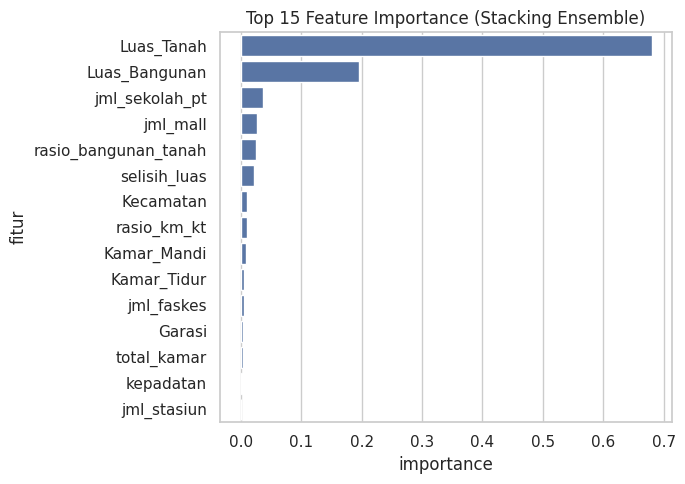

In [41]:
fig, ax = plt.subplots(figsize=(7,5))
top15 = imp_df.head(15)
sns.barplot(data=top15, y="fitur", x="importance", ax=ax)
ax.set_title(f"Top 15 Feature Importance ({nama_model_terbaik})")
plt.tight_layout()
plt.show()

### 5.4 Explainable AI dengan SHAP

Digunakan **SHAP (SHapley Additive exPlanations)** untuk menjelaskan kontribusi fitur per prediksi. `shap.TreeExplainer` untuk model pohon, `shap.Explainer` generik (berbasis permutasi pada sampel data uji terbatas) untuk Stacking Ensemble.

In [42]:
import shap

X_test_transformed = best_pipe.named_steps["preprocessor"].transform(X_test)
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()
feature_names_transformed = (fitur_numerik +
    list(best_pipe.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(fitur_kategorikal)))
X_test_transformed = pd.DataFrame(X_test_transformed, columns=feature_names_transformed, index=X_test.index)

model_obj = best_pipe.named_steps["model"]
bisa_dekomposisi = isinstance(model_obj, StackingRegressor) and isinstance(getattr(model_obj, "final_estimator_", None), Ridge)

def jelaskan_shap(data_df):
    '''data_df: fitur yang SUDAH ditransformasi preprocessor. Return shap.Explanation.'''
    if best_model_is_tree:
        return shap.TreeExplainer(model_obj)(data_df)

    elif bisa_dekomposisi:
        # Mekanisme A: dekomposisi linier -- SHAP EKSAK & cepat.
        # Valid karena meta-learner Stacking = Ridge (linier):
        # shap(prediksi_akhir) = sum_i( koef_meta_i * shap(base_learner_i) )
        meta = model_obj.final_estimator_
        base_names  = [nama for nama, _ in model_obj.estimators]
        base_models = model_obj.estimators_
        background_lokal = shap.sample(X_test_transformed, 100, random_state=SEED)

        shap_total = np.zeros((len(data_df), data_df.shape[1]))
        base_value_total = meta.intercept_
        for koef, nama, base_model in zip(meta.coef_, base_names, base_models):
            expl_base = (shap.LinearExplainer(base_model, background_lokal)
                         if isinstance(base_model, Ridge) else shap.TreeExplainer(base_model))
            sv_base = expl_base(data_df)
            shap_total += koef * sv_base.values
            base_value_total += koef * np.mean(sv_base.base_values)

        return shap.Explanation(
            values=shap_total,
            base_values=np.full(len(data_df), base_value_total),
            data=data_df.values,
            feature_names=list(data_df.columns),
        )

    else:
        # Mekanisme B (fallback): Permutation Explainer generik --
        # dipakai HANYA kalau meta-learner bukan model linier.
        for est in getattr(model_obj, "estimators_", []):
            if hasattr(est, "n_jobs"):
                est.n_jobs = -1
        if hasattr(model_obj, "n_jobs"):
            model_obj.n_jobs = -1
        background_lokal = shap.sample(X_test_transformed, 20, random_state=SEED)
        predict_fn = lambda data: model_obj.predict(pd.DataFrame(data, columns=feature_names_transformed))
        expl = shap.Explainer(predict_fn, background_lokal, algorithm="permutation")
        return expl(data_df, max_evals=2 * data_df.shape[1] + 1)

if best_model_is_tree:
    X_shap_display = X_test_transformed
else:
    N_SAMPLE_SHAP = 200 if bisa_dekomposisi else 30   # dekomposisi jauh lebih cepat -> sampel lebih besar
    X_shap_display = X_test_transformed.sample(n=min(N_SAMPLE_SHAP, len(X_test_transformed)), random_state=SEED)

print("Mekanisme SHAP dipakai:",
      "TreeExplainer" if best_model_is_tree else
      "Dekomposisi linier (Mekanisme A — eksak & cepat)" if bisa_dekomposisi else
      "Permutation Explainer (Mekanisme B — fallback)")

shap_values = jelaskan_shap(X_shap_display)
print("Shape SHAP values:", shap_values.values.shape)

Mekanisme SHAP dipakai: Dekomposisi linier (Mekanisme A — eksak & cepat)
Shape SHAP values: (200, 50)


**Global importance (SHAP summary — beeswarm).** Menunjukkan besar dan arah kontribusi fitur.

/tmp/ipykernel_48058/917619797.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap_display, max_display=15, show=False)


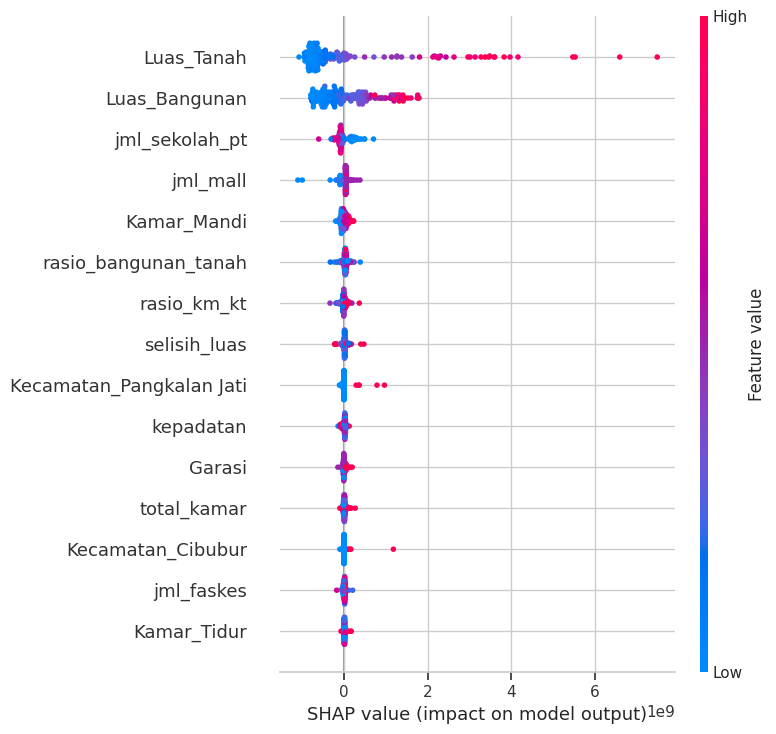

In [43]:
shap.summary_plot(shap_values, X_shap_display, max_display=15, show=False)
plt.tight_layout()
plt.show()

**Global importance (SHAP — bar/mean |SHAP|).** Ranking ini dapat dibandingkan dengan `imp_df`.

/tmp/ipykernel_48058/1500898478.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap_display, plot_type="bar", max_display=15, show=False)


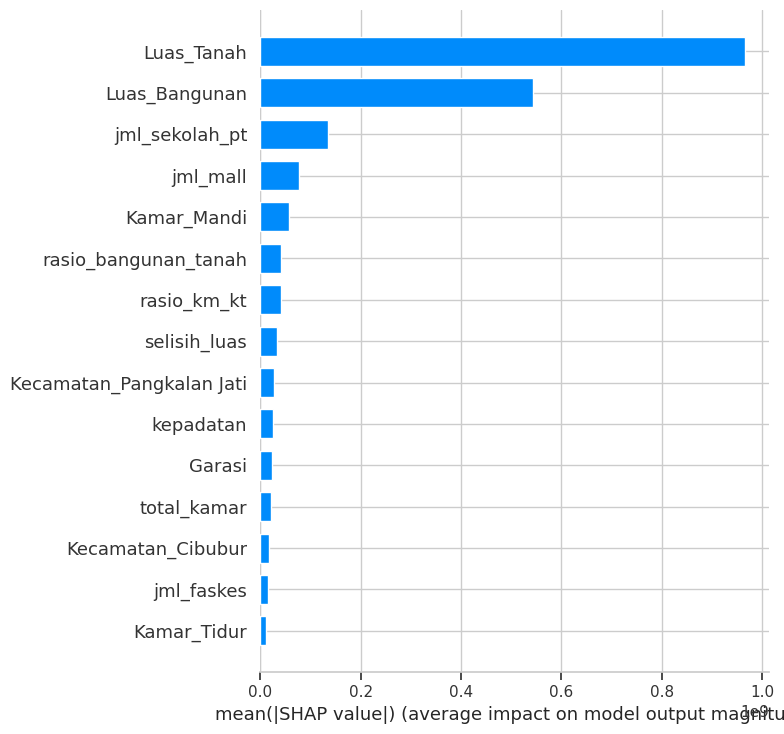

In [44]:
shap.summary_plot(shap_values, X_shap_display, plot_type="bar", max_display=15, show=False)
plt.tight_layout()
plt.show()

**Dependence plot.** Memeriksa hubungan antara fitur dan kontribusi SHAP-nya.

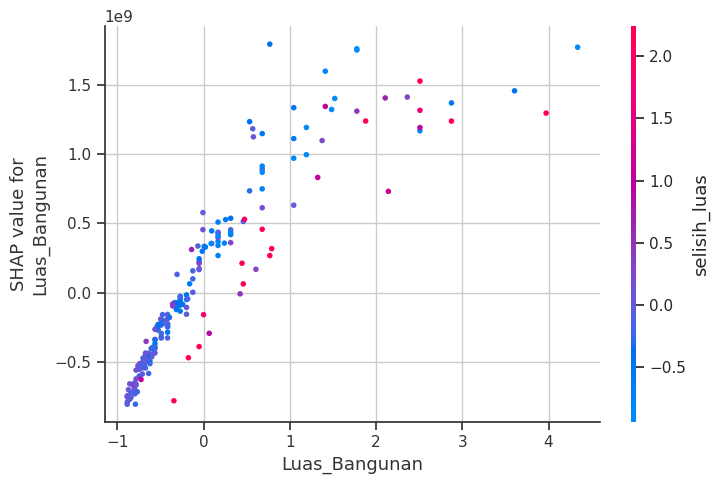

In [45]:
fitur_dependence = "Luas_Bangunan" if "Luas_Bangunan" in feature_names_transformed else feature_names_transformed[0]
shap.dependence_plot(fitur_dependence, shap_values.values, X_shap_display, show=False)
plt.tight_layout()
plt.show()

**Penjelasan untuk satu prediksi individual (waterfall plot).** Selain melihat pola global, SHAP juga bisa menjelaskan *mengapa* satu rumah tertentu diprediksi seharga sekian — berguna untuk kebutuhan bisnis seperti menjelaskan estimasi harga ke calon pembeli/penjual secara transparan.

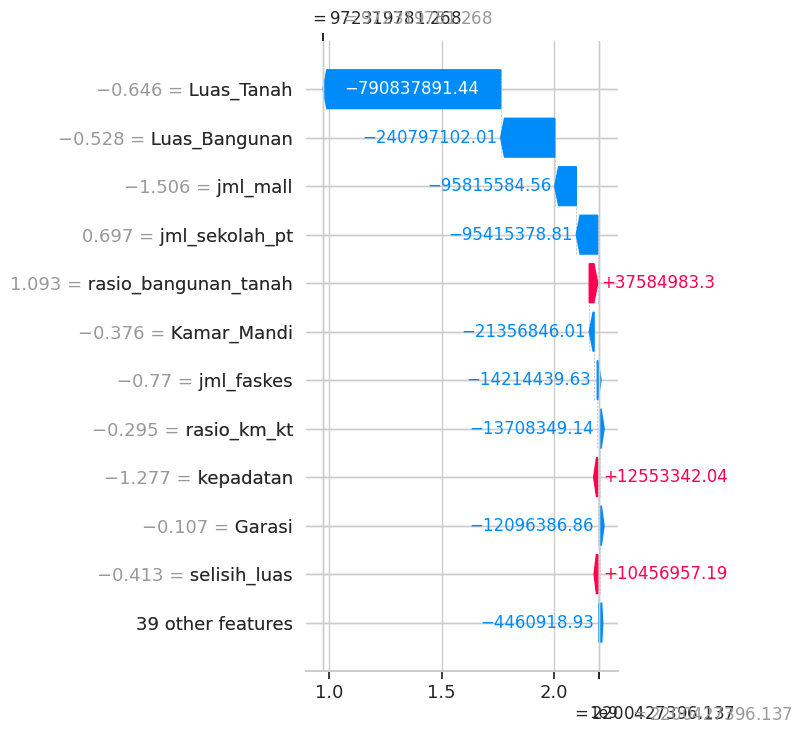

Harga aktual  : Rp 990,000,000
Harga prediksi: Rp 972,319,781


In [46]:
idx_contoh = 0
shap.plots.waterfall(shap_values[idx_contoh], max_display=12, show=False)
plt.tight_layout()
plt.show()

idx_asli = X_shap_display.index[idx_contoh]
print("Harga aktual  :", f"Rp {y_test.loc[idx_asli]:,.0f}")
print("Harga prediksi:", f"Rp {best_pipe.predict(X_test.loc[[idx_asli]])[0]:,.0f}")

### 5.5 Analisis Residual

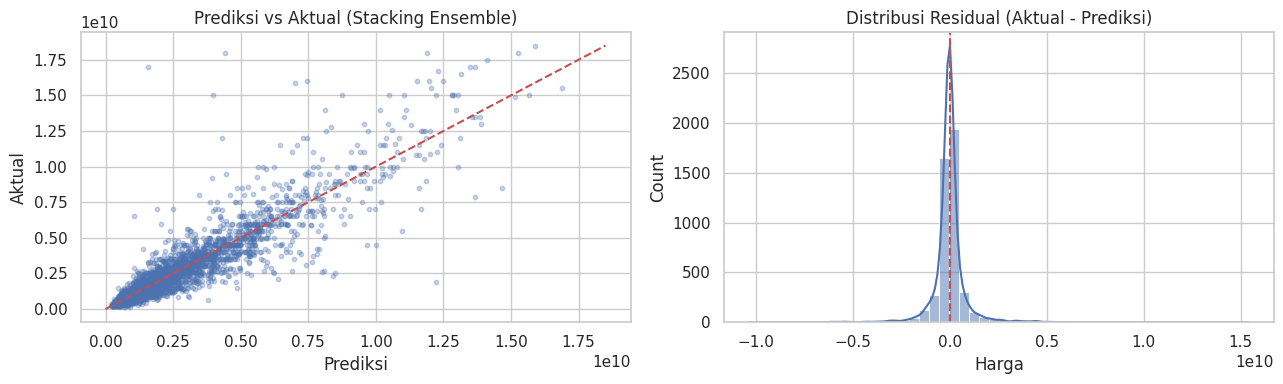

In [47]:
residual = y_test - pred_terbaik
fig, axes = plt.subplots(1, 2, figsize=(13,4))

axes[0].scatter(pred_terbaik, y_test, alpha=0.3, s=10)
lims = [0, max(y_test.max(), pred_terbaik.max())]
axes[0].plot(lims, lims, 'r--')
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Aktual")
axes[0].set_title(f"Prediksi vs Aktual ({nama_model_terbaik})")

sns.histplot(residual, bins=50, ax=axes[1], kde=True)
axes[1].set_title("Distribusi Residual (Aktual - Prediksi)")
axes[1].axvline(0, color="r", linestyle="--")
plt.tight_layout()
plt.show()

### 5.6 Limitasi

Beberapa limitasi meliputi: kompleksitas kolom `Kecamatan`, tanpa variabel infrastruktur eksternal, penghapusan baris tidak valid, potensi distorsi MAPE, budget trial Optuna terbatas, estimasi SHAP untuk Stacking Ensemble (generik), dan perbandingan *permutation importance* dengan `feature_importances_` hanya pada ranking.

## 6. Deployment

In [48]:
import joblib
import os

nama_file_model = f"model_prediksi_harga_rumah_depok_{nama_model_terbaik.lower().replace(' ', '_')}.pkl"
joblib.dump(best_pipe, nama_file_model, compress=3)  # compress mengecilkan ukuran file secara signifikan

ukuran_mb = os.path.getsize(nama_file_model) / (1024 ** 2)
print(f"Model '{nama_model_terbaik}' berhasil disimpan sebagai '{nama_file_model}' ({ukuran_mb:.1f} MB)")
if ukuran_mb > 100:
    print("Ukuran > 100 MB — GitHub akan menolak push biasa. Pertimbangkan Git LFS, "
          "kurangi n_estimators RF/jumlah pohon, atau host file model terpisah lalu unduh saat app start.")
elif ukuran_mb > 25:
    print("Catatan: ukuran cukup besar (>25 MB), masih aman untuk GitHub tapi loading pertama di Streamlit Cloud agak lambat.")

joblib.dump(kecamatan_mapping, "kecamatan_mapping_depok.pkl")
print("Kamus pemetaan area -> kecamatan resmi disimpan sebagai 'kecamatan_mapping_depok.pkl'")

Model 'Stacking Ensemble' berhasil disimpan sebagai 'model_prediksi_harga_rumah_depok_stacking_ensemble.pkl' (59.7 MB)
Catatan: ukuran cukup besar (>25 MB), masih aman untuk GitHub tapi loading pertama di Streamlit Cloud agak lambat.
Kamus pemetaan area -> kecamatan resmi disimpan sebagai 'kecamatan_mapping_depok.pkl'


### 6.2 Contoh Fungsi Prediksi untuk Rumah Baru

Fungsi `prediksi_harga` mengambil atribut rumah dan kecamatan. Jika `jelaskan=True`, ia menampilkan kontribusi SHAP.

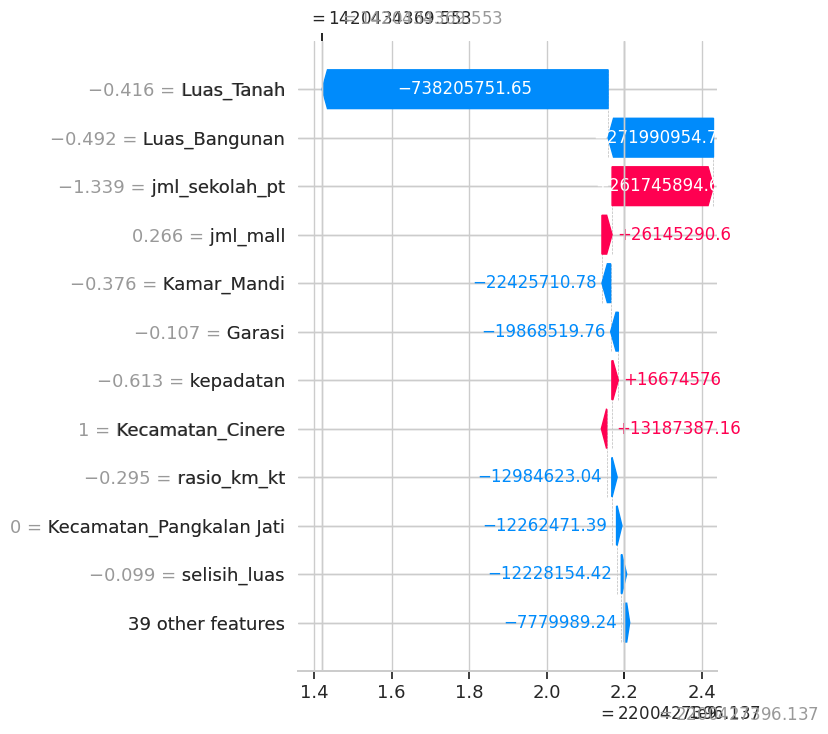

Estimasi harga: Rp 1,420,434,370


In [51]:
def prediksi_harga(kamar_tidur, kamar_mandi, garasi, luas_tanah, luas_bangunan, kecamatan, jelaskan=False):
    # Map the input kecamatan to its official/cleaned version
    kecamatan_resmi = kecamatan_mapping.get(kecamatan, kecamatan) # Use .get to handle cases where input may not be in mapping directly

    # Lookup additional spatial variables from df_variabel_tambahan
    # Ensure df_variabel_tambahan is accessible in this scope if not global
    # We expect 'kec' column in df_variabel_tambahan to match 'Kecamatan_Resmi'
    variabel_spasial = df_variabel_tambahan[df_variabel_tambahan['kec'] == kecamatan_resmi]

    if variabel_spasial.empty:
        # Handle case where kecamatan_resmi is not found in df_variabel_tambahan
        # For now, default to 0 or raise an error
        jml_faskes = jml_stasiun = jml_mall = jml_sekolah_pt = kepadatan = 0
        print(f"Warning: Spatial data not found for kecamatan: {kecamatan_resmi}. Using default 0 for spatial features.")
    else:
        # Extract the values, assuming there's only one matching row
        row = variabel_spasial.iloc[0]
        jml_faskes = row['jml_faskes']
        jml_stasiun = row['jml_stasiun']
        jml_mall = row['jml_mall']
        jml_sekolah_pt = row['jml_sekolah_pt']
        kepadatan = row['kepadatan']

    rasio_bangunan_tanah = luas_bangunan / luas_tanah
    selisih_luas = luas_tanah - luas_bangunan
    total_kamar = kamar_tidur + kamar_mandi
    rasio_km_kt = kamar_mandi / kamar_tidur

    data_baru = pd.DataFrame([{
        "Kamar_Tidur": kamar_tidur,
        "Kamar_Mandi": kamar_mandi,
        "Garasi": garasi,
        "Luas_Tanah": luas_tanah,
        "Luas_Bangunan": luas_bangunan,
        "rasio_bangunan_tanah": rasio_bangunan_tanah,
        "selisih_luas": selisih_luas,
        "total_kamar": total_kamar,
        "rasio_km_kt": rasio_km_kt,
        "Kecamatan": kecamatan,
        "jml_faskes": jml_faskes,
        "jml_stasiun": jml_stasiun,
        "jml_mall": jml_mall,
        "jml_sekolah_pt": jml_sekolah_pt,
        "kepadatan": kepadatan
    }])
    pred = best_pipe.predict(data_baru)[0]

    if jelaskan:
        # The preprocessor expects 'Kecamatan_Resmi' during fit, but here we provide 'Kecamatan' (raw) for the OHE.
        # The features_names_transformed will be based on the preprocessor's fit, which included the spatial features.
        # This part assumes the `Kecamatan` column in data_baru maps correctly in the preprocessor's categorical transformer.

        # The `X_test` used in the `permutation_importance` earlier was `df_processed.drop(columns=["Harga", "Kecamatan_Resmi"])`
        # So it means `X_test` contained the raw `Kecamatan` column and the spatial columns. `feature_names_transformed` reflects this.

        data_transformed = best_pipe.named_steps["preprocessor"].transform(data_baru)
        if hasattr(data_transformed, "toarray"):
            data_transformed = data_transformed.toarray()
        data_transformed = pd.DataFrame(data_transformed, columns=feature_names_transformed)

        shap_baru = jelaskan_shap(data_transformed)

        shap.plots.waterfall(shap_baru[0], max_display=12, show=False)
        plt.tight_layout()
        plt.show()

    return pred

contoh = prediksi_harga(kamar_tidur=3, kamar_mandi=2, garasi=1,
                         luas_tanah=100, luas_bangunan=90, kecamatan="Cinere", jelaskan=True)
print(f"Estimasi harga: Rp {contoh:,.0f}")

### 6.3 Rencana Lanjutan (Next Steps)

Pengembangan selanjutnya: menggabungkan variabel eksternal, menambahkan fitur rekayasa dari perspektif pengembang, menguji pembelajar dasar alternatif pada Stacking Ensemble, memperluas budget tuning Optuna, menerapkan transformasi logaritmik pada target, deployment model via API/Streamlit, dan implementasi monitoring model.